# Warfarine PK/PD — Reproduction du case study Monolix avec **nlmixr2**

Ce notebook reproduit, étape par étape, le tutorial MonolixSuite **“Modeling the pharmacokinetics and pharmacodynamics of warfarin in healthy volunteers”** en le transposant dans l’écosystème **nlmixr2 / rxode2** (R).

> ⚠️ Ce notebook est prévu pour un **kernel R (IRkernel)** dans Jupyter.

## Plan
1. Données & exploration (PK + PCA)
2. Développement PK : 1 compartiment → ajout d’un *lag time* → (test 2 compartiments) → choix du modèle
3. Développement statistique PK : erreur résiduelle (combined1 vs combined2)
4. Modèle covariables PK : effet du poids sur V (loi de puissance)
5. Développement PK/PD : comparaison *effect compartment* vs *turnover* (inhibition de production partielle + sigmoidicité)
6. Simulations : essai clinique virtuel (groupe avec *loading* vs sans), endpoint PCA(96h) < 35%, réplications avec incertitude des paramètres

---


In [1]:
# =============================================================================
# 0) Setup : packages et options
# =============================================================================

# Installation (à exécuter une seule fois si besoin)
 install.packages(c(
   "nlmixr2", "rxode2", "nlmixr2data",
   "dplyr", "tidyr", "purrr", "ggplot2", "readr",
   "stringr", "broom", "MASS"
 ))

library(nlmixr2)
library(rxode2)
library(dplyr)
library(tidyr)
library(purrr)
library(ggplot2)
library(stringr)

set.seed(42)
rxSetSeed(42)

# Pour un affichage propre
options(width = 120)
theme_set(theme_bw())


Installation des packages dans 'C:/Users/abdel/AppData/Local/R/win-library/4.4'
(car 'lib' n'est pas spécifié)

Warning message:
"impossible d'accéder à l'index de l'entrepôt https://cran.r-project.org/src/contrib:
  impossible d'ouvrir l'URL 'https://cran.r-project.org/src/contrib/PACKAGES'"
Warning message:
"les packages 'nlmixr2', 'rxode2', 'nlmixr2data', 'dplyr', 'tidyr', 'purrr', 'ggplot2', 'readr', 'stringr', 'broom', 'MASS' ne sont pas disponibles for this version of R

Des versions de ces packages pour votre version de R sont peut-être disponibles ailleurs,
Voyez des idées à
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"
Warning message:
"impossible d'accéder à l'index de l'entrepôt https://cran.r-project.org/bin/windows/contrib/4.4:
  impossible d'ouvrir l'URL 'https://cran.r-project.org/bin/windows/contrib/4.4/PACKAGES'"
Warning message:
"le package 'nlmixr2' a été compilé avec la version R 4.4.3"
── Attaching packages ─────────────────────

In [2]:
# =============================================================================
# 1) Données : import + formatage (Monolix warfarin_data.txt ou nlmixr2data::warfarin)
# =============================================================================

read_warfarin <- function() {
  # Option 1 : dataset intégré (souvent le plus simple)
  if (requireNamespace("nlmixr2data", quietly = TRUE)) {
    dat <- nlmixr2data::warfarin
    return(dat)
  }

  # Option 2 : téléchargement direct du fichier Monolix (si nlmixr2data absent)
  url <- "https://monolixsuite.slp-software.com/__attachments/49840458/warfarin_data.txt"
  tmp <- tempfile(fileext = ".txt")
  download.file(url, tmp, quiet = TRUE)
  dat <- read.table(tmp, header = TRUE, stringsAsFactors = FALSE)
  dat
}

dat_raw <- read_warfarin()

# Standardisation des noms + types
dat <- dat_raw %>%
  rename_with(tolower) %>%
  mutate(
    id   = as.integer(id),
    time = as.numeric(time),
    amt  = as.numeric(amt),
    dv   = as.numeric(dv),
    wt   = as.numeric(wt),
    age  = as.numeric(age)
  )

# Gestion des "." potentiels si import depuis warfarin_data.txt
if (is.character(dat$dv))  dat$dv  <- as.numeric(ifelse(dat$dv  == ".", NA, dat$dv))
if (is.character(dat$amt)) dat$amt <- as.numeric(ifelse(dat$amt == ".", 0,  dat$amt))

# Ajout evid si absent : 1 = dose, 0 = observation
if (!"evid" %in% names(dat)) {
  dat <- dat %>% mutate(evid = ifelse(!is.na(amt) & amt > 0, 1L, 0L))
}

# Harmonisation dvid (Monolix : 1=PK, 2=PD ; nlmixr2data : cp/pca)
if ("dvid" %in% names(dat)) {
  if (is.numeric(dat$dvid) || is.integer(dat$dvid)) {
    dat <- dat %>% mutate(dvid = factor(dvid, levels = c(1, 2), labels = c("cp", "pca")))
  } else {
    dat <- dat %>% mutate(dvid = as.factor(dvid))
  }
} else {
  stop("La colonne dvid est requise (cp vs pca).")
}

# Harmonisation sex
if ("sex" %in% names(dat)) {
  if (is.numeric(dat$sex) || is.integer(dat$sex)) {
    # Convention fréquente : 1=male, 0=female
    dat <- dat %>% mutate(sex = factor(sex, levels = c(0, 1), labels = c("female", "male")))
  } else {
    dat <- dat %>% mutate(sex = as.factor(sex))
  }
}

# Aperçu
glimpse(dat)
summary(dat$dvid)


Rows: 515
Columns: 9
$ id   <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, …
$ time <dbl> 0.0, 0.5, 1.0, 2.0, 3.0, 6.0, 9.0, 12.0, 24.0, 24.0, 36.0, 36.0, 48.0, 48.0, 72.0, 72.0, 96.0, 120.0, 144…
$ amt  <dbl> 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10…
$ dv   <dbl> 0.0, 0.0, 1.9, 3.3, 6.6, 9.1, 10.8, 8.6, 5.6, 44.0, 4.0, 27.0, 2.7, 28.0, 0.8, 31.0, 60.0, 65.0, 71.0, 0.…
$ dvid <fct> cp, cp, cp, cp, cp, cp, cp, cp, cp, pca, cp, pca, cp, pca, cp, pca, pca, pca, pca, cp, pca, cp, pca, cp, …
$ evid <int> 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, …
$ wt   <dbl> 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.7, 66.…
$ age  <dbl> 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 5…
$ sex  <fct> male, 

cp pca 
283 232

## 2) Exploration des données

On visualise :
- Les concentrations de warfarine (PK, `dvid == "cp"`)
- L’activité du complexe prothrombinique (PCA, PD, `dvid == "pca"`)
- La relation effet–concentration (hystérésis / délai d’effet)

Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."


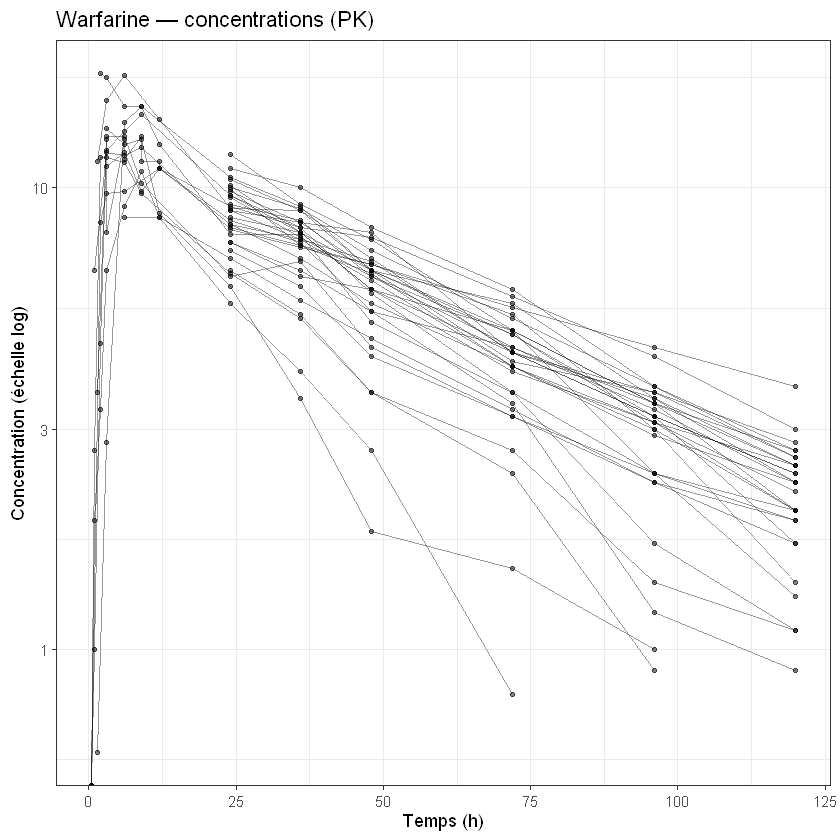

Warning message:
"Removed 47 rows containing missing values or values outside the scale range (`geom_path()`)."
Warning message:
"Removed 47 rows containing missing values or values outside the scale range (`geom_point()`)."


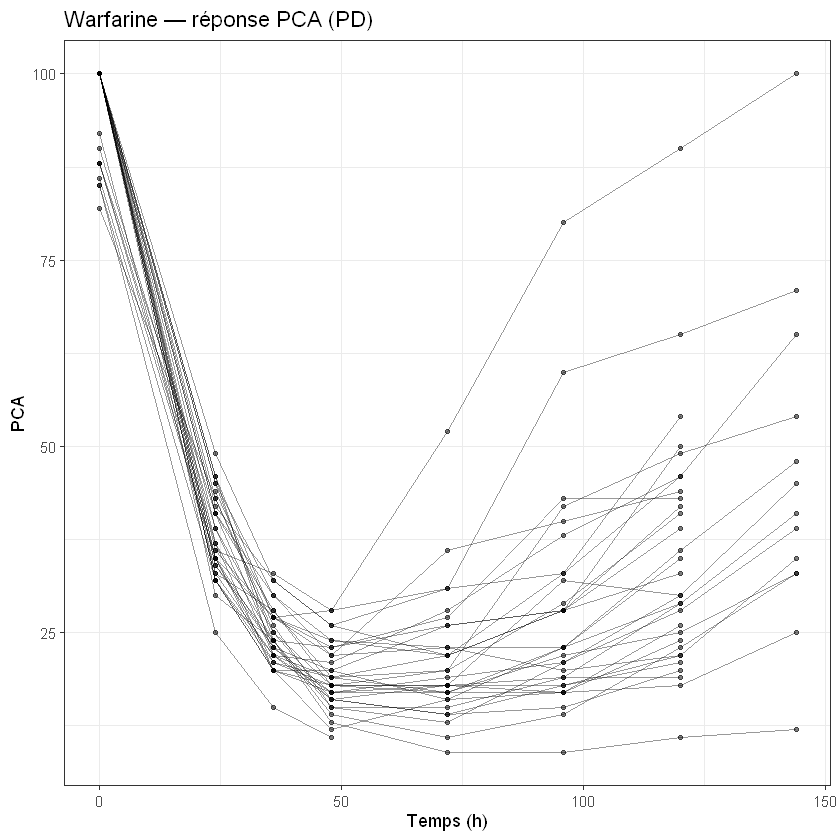

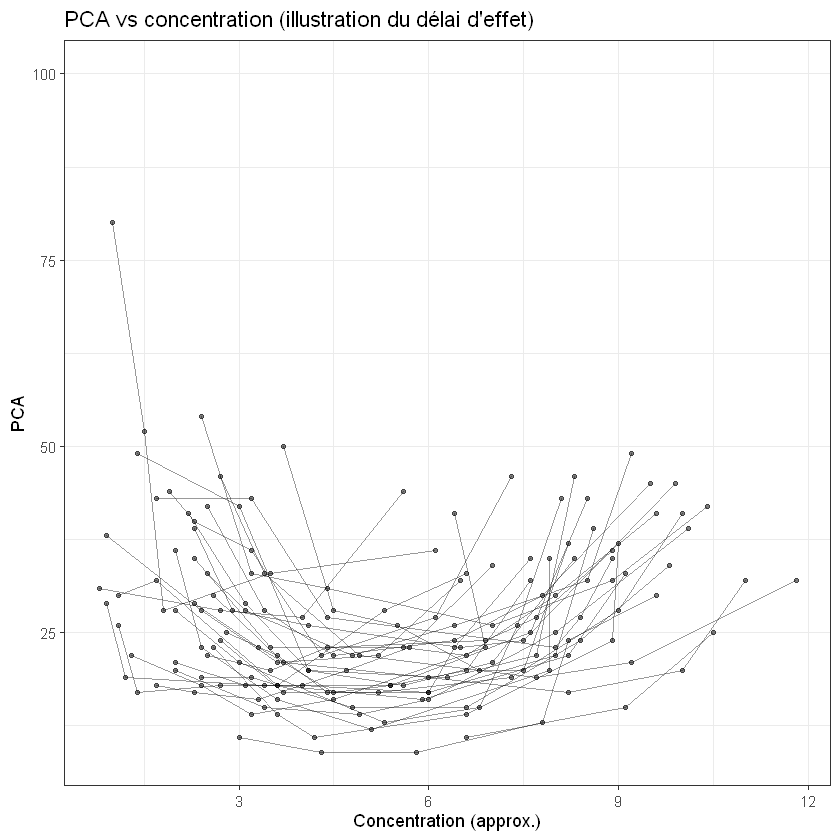

In [3]:
# =============================================================================
# Exploration : profils individuels
# =============================================================================

dat_pk <- dat %>% filter(dvid == "cp" | evid == 1)
dat_pd <- dat %>% filter(dvid == "pca" | evid == 1)

p_pk <- ggplot(dat_pk %>% filter(evid == 0), aes(x = time, y = dv, group = id)) +
  geom_line(alpha = 0.4) +
  geom_point(alpha = 0.5, size = 1) +
  scale_y_log10() +
  labs(title = "Warfarine — concentrations (PK)", x = "Temps (h)", y = "Concentration (échelle log)")

p_pd <- ggplot(dat_pd %>% filter(evid == 0), aes(x = time, y = dv, group = id)) +
  geom_line(alpha = 0.4) +
  geom_point(alpha = 0.5, size = 1) +
  labs(title = "Warfarine — réponse PCA (PD)", x = "Temps (h)", y = "PCA")

print(p_pk)
print(p_pd)

# -----------------------------------------------------------------------------
# Effet vs concentration (à la Monolix : interpolation nécessaire)
# On crée une table CP(t) interpolée par individu, puis on joint aux points PCA.
# -----------------------------------------------------------------------------
cp_interp <- dat_pk %>%
  filter(evid == 0) %>%
  select(id, time, cp = dv) %>%
  group_by(id) %>%
  arrange(time) %>%
  tidyr::complete(time = seq(min(time), max(time), by = 1)) %>%
  tidyr::fill(cp, .direction = "downup") %>%
  ungroup()

pca_points <- dat_pd %>% filter(evid == 0) %>% select(id, time, pca = dv)

effconc <- pca_points %>%
  left_join(cp_interp, by = c("id", "time"))

p_ec <- ggplot(effconc, aes(x = cp, y = pca, group = id)) +
  geom_path(alpha = 0.4) +
  geom_point(alpha = 0.5, size = 1) +
  labs(title = "PCA vs concentration (illustration du délai d'effet)", x = "Concentration (approx.)", y = "PCA")

print(p_ec)


## 3) Développement PK (comme dans Monolix)

### 3.1 Modèle de départ
- Administration orale
- Absorption d’ordre 1
- 1 compartiment, élimination linéaire (paramétrisation CL / V)

### 3.2 Ajout d’un *lag time* (Tlag)
Dans le case study, l’ajout d’un délai d’absorption améliore l’ajustement des premiers points.

### 3.3 (Option) Test d’un modèle 2 compartiments
Dans le case study, l’ajout d’un 2e compartiment donne des estimations moins stables/plus incertaines → on retient **1 compartiment + Tlag**.


In [4]:
# =============================================================================
# Helpers : lancement robuste (pour que le notebook reste "fonctionnel")
# =============================================================================

safe_nlmixr <- function(model, data, est = "saem", seed = 1,
                       control = saemControl(print = 50),
                       table = tableControl(cwres = TRUE, npde = TRUE)) {
  set.seed(seed); rxSetSeed(seed)
  out <- tryCatch(
    nlmixr(model, data, est = est, control = control, table = table),
    error = function(e) {
      message("⚠️ Échec estimation : ", conditionMessage(e))
      NULL
    }
  )
  out
}

metrics <- function(fit, name) {
  if (is.null(fit)) return(tibble(model = name, AIC = NA_real_, BIC = NA_real_, logLik = NA_real_))
  tibble(
    model = name,
    AIC = AIC(fit),
    BIC = BIC(fit),
    logLik = as.numeric(logLik(fit))
  )
}

# =============================================================================
# 3.1 PK : 1 compartiment, pas de délai (combined1 comme point de départ Monolix)
# =============================================================================
pk_1cmt_c1 <- function() {
  ini({
    tka <- log(1.0)
    tcl <- log(0.1)
    tv  <- log(10)

    eta.ka ~ 0.3
    eta.cl ~ 0.1
    eta.v  ~ 0.1

    add.sd  <- 0.1
    prop.sd <- 0.1
  })
  model({
    ka <- exp(tka + eta.ka)
    cl <- exp(tcl + eta.cl)
    v  <- exp(tv  + eta.v)

    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr

    cp = centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined1() | cp
  })
}

fit_pk_r01 <- safe_nlmixr(pk_1cmt_c1, dat_pk, seed = 101)

# =============================================================================
# 3.2 PK : 1 compartiment + Tlag
# =============================================================================
pk_1cmt_tlag_c1 <- function() {
  ini({
    ttlag <- log(0.5)
    tka   <- log(1.0)
    tcl   <- log(0.1)
    tv    <- log(10)

    eta.tlag ~ 0.1
    eta.ka   ~ 0.3
    eta.cl   ~ 0.1
    eta.v    ~ 0.1

    add.sd  <- 0.1
    prop.sd <- 0.1
  })
  model({
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv    + eta.v)

    alag(depot) = tlag

    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr

    cp = centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined1() | cp
  })
}

fit_pk_r02 <- safe_nlmixr(pk_1cmt_tlag_c1, dat_pk, seed = 102)

# =============================================================================
# 3.3 PK : 2 compartiments + Tlag (optionnel, peut être instable)
# =============================================================================
pk_2cmt_tlag_c1 <- function() {
  ini({
    ttlag <- log(0.5)
    tka   <- log(1.0)
    tcl   <- log(0.1)
    tv    <- log(10)
    tq    <- log(5.0)
    tvp   <- log(20)

    eta.tlag ~ 0.1
    eta.ka   ~ 0.3
    eta.cl   ~ 0.1
    eta.v    ~ 0.1
    
    add.sd  <- 0.1
    prop.sd <- 0.1
  })
  model({
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv    + eta.v)
    q    <- exp(tq)
    vp   <- exp(tvp)

    alag(depot) = tlag

    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr - (q / v) * centr + (q / vp) * peri
    d/dt(peri)  =  (q / v) * centr - (q / vp) * peri

    cp = centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined1() | cp
  })
}

fit_pk_r03 <- safe_nlmixr(pk_2cmt_tlag_c1, dat_pk, seed = 103)

# -----------------------------------------------------------------------------
# Comparaison (AIC/BIC) des structures
# -----------------------------------------------------------------------------
bind_rows(
  metrics(fit_pk_r01, "r01: 1cmt, no delay"),
  metrics(fit_pk_r02, "r02: 1cmt + Tlag"),
  metrics(fit_pk_r03, "r03: 2cmt + Tlag (option)")
) %>% arrange(BIC)


 

 

 

 

ℹ parameter labels from comments are typically ignored in non-interactive mode

ℹ Need to run with the source intact to parse comments

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

using C compiler: 'gcc.exe (GCC) 13.3.0'


ℹ calculate uninformed etas

ℹ done

params:	tka	tcl	tv	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

using C compiler: 'gcc.exe (GCC) 13

model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
r02: 1cmt + Tlag,781.8434,817.0979,-380.9217
r03: 2cmt + Tlag (option),817.0512,859.3567,-396.5256
"r01: 1cmt, no delay",899.6142,927.8178,-441.8071


## 4) Développement statistique PK : erreur résiduelle (combined1 → combined2)

Dans le case study Monolix, la section “Proposal” suggère de passer de **combined1** à **combined2**.

Dans rxode2/nlmixr2 :
- `combined1()` : combinaison sur l’écart-type
- `combined2()` : combinaison sur la variance (défaut si non spécifié)

On refitte le modèle retenu (1cmt+Tlag) avec `combined2()` et on compare les critères.


In [5]:
# =============================================================================
# 4) Erreur résiduelle : combined1 vs combined2 sur le modèle 1cmt+Tlag
# =============================================================================

# Base = modèle avec estimés du fit précédent si dispo, sinon le modèle "de base"
base_ui <- if (!is.null(fit_pk_r02) && !is.null(fit_pk_r02$finalUi)) {
  fit_pk_r02$finalUi
} else {
  pk_1cmt_tlag_c1
}

# Forcer la ligne d'erreur (remplacement via model piping)
pk_tlag_c1_init <- base_ui %>%
  model({ cp ~ add(add.sd) + prop(prop.sd) + combined1() })

pk_tlag_c2_init <- base_ui %>%
  model({ cp ~ add(add.sd) + prop(prop.sd) + combined2() })

# Si fit_pk_r02 existe déjà et correspond à combined1, inutile de le re-fitter
fit_pk_r02_c1 <- if (!is.null(fit_pk_r02)) fit_pk_r02 else safe_nlmixr(pk_tlag_c1_init, dat_pk, seed = 104)

# Fit combined2
fit_pk_r02_c2 <- safe_nlmixr(pk_tlag_c2_init, dat_pk, seed = 104)

bind_rows(
  metrics(fit_pk_r02_c1, "r02: 1cmt+Tlag, combined1"),
  metrics(fit_pk_r02_c2, "r02b: 1cmt+Tlag, combined2")
) %>% arrange(BIC)

fit_pk_struct_final <- if (!is.null(fit_pk_r02_c2)) fit_pk_r02_c2 else fit_pk_r02_c1

→ significant model change detected

→ removed from model: '$control'

→ significant model change detected

→ removed from model: '$control'

 

 

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	ttlag	tka	tcl	tv	V(eta.tlag)	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

using C compiler: 'gcc.exe (GCC) 13.3.0'


→ Calculating res

model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
"r02b: 1cmt+Tlag, combined2",760.3437,795.5982,-370.1718
"r02: 1cmt+Tlag, combined1",781.8434,817.0979,-380.9217


## 5) Covariables PK : effet du poids sur V (loi de puissance)

Dans le case study Monolix, la covariable la plus significative est **wt sur V** (relation puissance).
On implémente :  
\[
V_i = V_{pop} \cdot (\frac{wt_i}{wt_{ref}})^{\beta_{wt,V}} \cdot e^{\eta_{V,i}}
\]


In [6]:
# =============================================================================
# 5) Ajout covariable poids sur V (power law)
# =============================================================================

stopifnot("wt" %in% names(dat_pk))

dat_pk <- dat_pk %>%
  group_by(id) %>%
  fill(wt, .direction = "downup") %>%
  ungroup()
  
wt_ref_num <- dat_pk %>%
  distinct(id, wt) %>%
  summarise(wt_ref = median(wt, na.rm = TRUE)) %>%
  pull(wt_ref) %>%
  as.numeric()

print(paste("Poids de référence (median) : ", wt_ref_num))

base_ui <- if (!is.null(fit_pk_struct_final) && !is.null(fit_pk_struct_final$finalUi)) {
  fit_pk_struct_final$finalUi
} else {
  # fallback si besoin (structure sans covariate)
  pk_1cmt_tlag_c2
}

pk_cov_ui <- base_ui  %>%
  model({
    ka <- exp(tka + eta.ka)
    cl <- exp(tcl + eta.cl)
    # On remplace la ligne de V par une formule avec covariable 
    v  <- exp(tv + b_wt_v * log(wt / wt_ref) + eta.v)
    cp <- centr / v
    cp ~ add(add.sd) + prop(prop.sd) + combined2()
  }) %>%
  ini({
    b_wt_v <- log(1.0)  # Exposant à estimer pour l'effet du poids sur V  
    wt_ref  = fixed(wt_ref_num) # Poids de référence (median) à fixer
  })

fit_pk_cov <- safe_nlmixr(pk_cov_ui, dat_pk, seed = 105)

bind_rows(
  metrics(fit_pk_struct_final, "PK sans covariate WT"),
  metrics(fit_pk_cov,          "PK + WT sur V")
) %>% arrange(BIC)

fit_pk_final <- if (!is.null(fit_pk_cov)) fit_pk_cov else fit_pk_struct_final

[1] "Poids de référence (median) :  71.65"


ℹ add covariate `b_wt_v`

ℹ add covariate `wt`

ℹ add covariate `wt_ref`

→ significant model change detected

→ removed from model: '$control'

ℹ promote `b_wt_v` to population parameter with initial estimate 0

ℹ change initial estimate of `b_wt_v` to `0`

ℹ promote `wt_ref` to population parameter with initial estimate 71.65

ℹ fix `wt_ref` to `71.65`

ℹ change initial estimate of `wt_ref` to `71.65`

 

 

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

using C compiler: 'gcc.exe (GCC) 13.3.0'


ℹ calculate uninformed etas

ℹ done

params:	ttlag	tka	tcl	tv	b_wt_v	V(eta.tlag)	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ findin

model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
PK + WT sur V,741.0162,779.7962,-359.5081
PK sans covariate WT,760.3437,795.5982,-370.1718


## 6) Diagnostics PK (GOF)

On produit quelques graphiques de base (observations vs prédictions, résidus vs temps).
> Selon votre installation, `nlmixr2` fournit déjà un tableau enrichi dans l’objet `fit` (CWRES/NPDE si demandés).


In [7]:
ap <- (fit_pk_final)
colnames(ap)

[1] "ID"       "TIME"     "DV"       "EPRED"    "ERES"     "NPDE"     "NPD"      "PDE"      "PD"       "PRED"    
[11] "RES"      "WRES"     "IPRED"    "IRES"     "IWRES"    "CPRED"    "CRES"     "CWRES"    "eta.tlag" "eta.ka"  
[21] "eta.cl"   "eta.v"    "depot"    "centr"    "tlag"     "ka"       "cl"       "v"        "tad"      "dosenum" 
[31] "wt"

Warning message in scale_y_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."


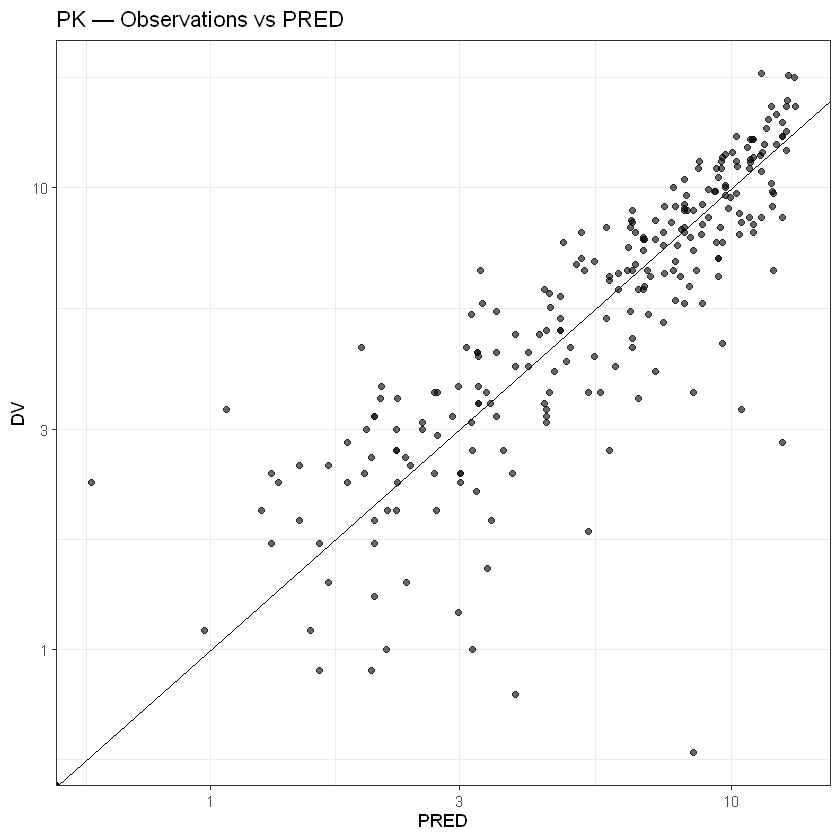

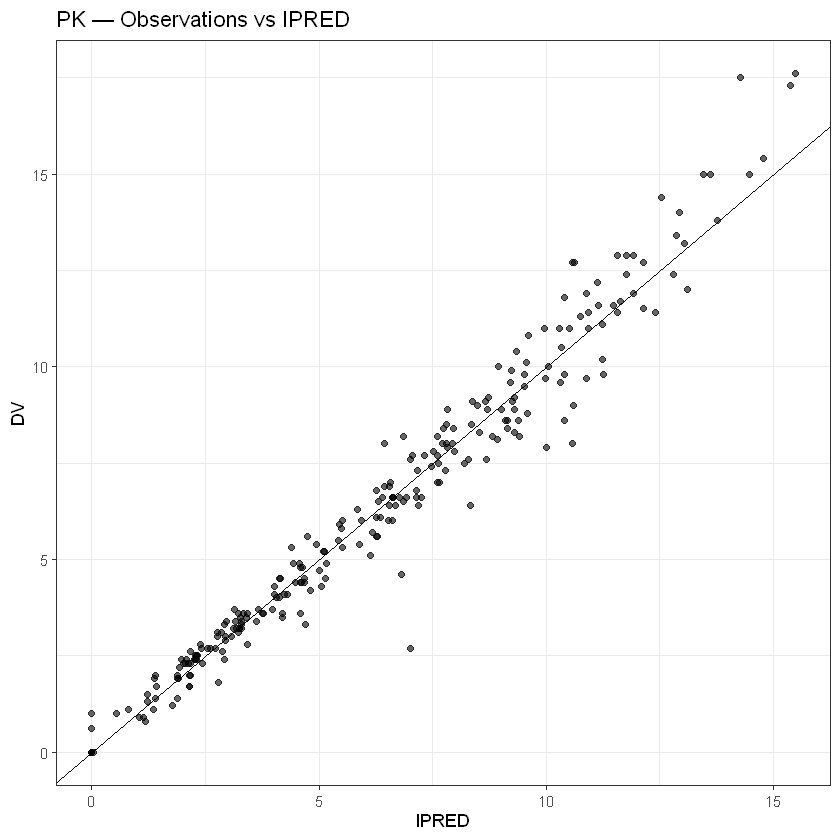

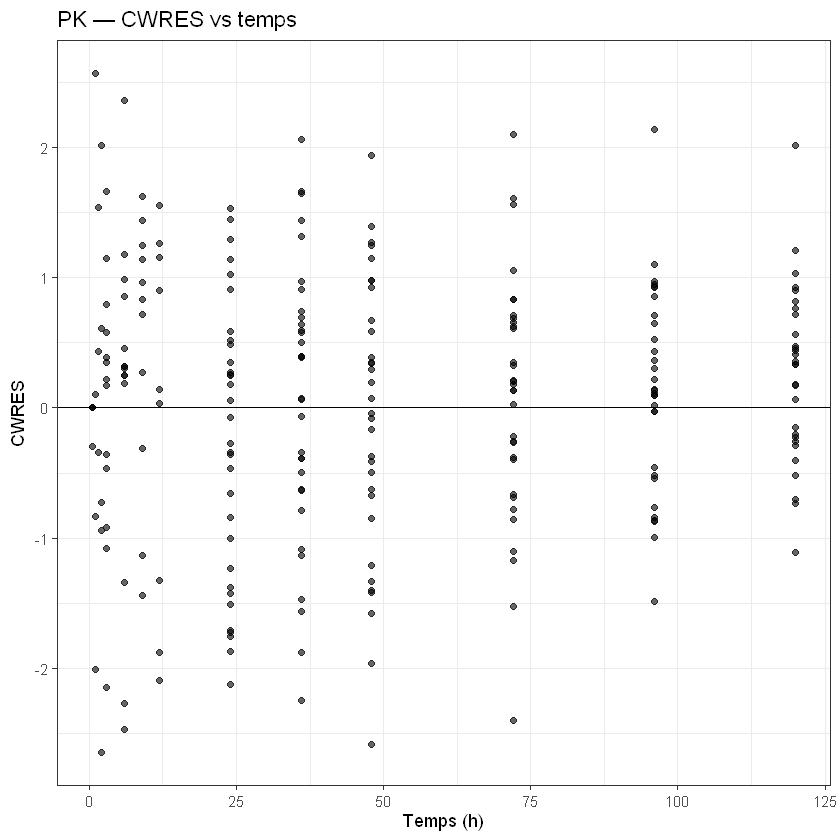

In [8]:
# =============================================================================
# 6) GOF : extraction des prédictions/résidus (augPred)
# =============================================================================

if (!is.null(fit_pk_final)) {
  ap <- fit_pk_final

  # Les colonnes peuvent varier selon versions; on s'adapte
  ap_df <- as.data.frame(ap)

  # Filtre PK uniquement
  ap_pk <- ap_df

  # Obs vs Pred
  if (all(c("DV", "PRED") %in% names(ap_pk))) {
    print(
      ggplot(ap_pk %>% filter(!is.na(DV)), aes(x = PRED, y = DV)) +
        geom_point(alpha = 0.6) +
        geom_abline(slope = 1, intercept = 0) +
        scale_y_log10() + scale_x_log10() +
        labs(title = "PK — Observations vs PRED", x = "PRED", y = "DV")
    )
  }

  # Obs vs IPred
  if (all(c("DV", "IPRED") %in% names(ap_pk))) {
    print(
      ggplot(ap_pk %>% filter(!is.na(DV)), aes(x = IPRED, y = DV)) +
        geom_point(alpha = 0.6) +
        geom_abline(slope = 1, intercept = 0) +
        labs(title = "PK — Observations vs IPRED", x = "IPRED", y = "DV")
    )
  }

  # CWRES vs TIME si dispo
  if (all(c("TIME", "CWRES") %in% names(ap_pk))) {
    print(
      ggplot(ap_pk %>% filter(!is.na(CWRES)), aes(x = TIME, y = CWRES)) +
        geom_hline(yintercept = 0) +
        geom_point(alpha = 0.6) +
        labs(title = "PK — CWRES vs temps", x = "Temps (h)", y = "CWRES")
    )
  }
}


## 7) Robustesse/convergence (analogue “Convergence assessment”)

Pour mimer l’idée Monolix (stabilité des estimations), on relance le **modèle PK final** sur plusieurs graines (seeds) et on compare les estimations.


In [9]:
# =============================================================================
# 7) Robustesse : plusieurs seeds (PK)
# =============================================================================

if (!is.null(fit_pk_final)) {
  seeds <- c(11, 22, 33, 44, 55)

  ui_pk <- if (!is.null(fit_pk_final$finalUi)) fit_pk_final$finalUi else fit_pk_final$ui
  fits <- purrr::map(seeds, ~ safe_nlmixr(ui_pk, dat_pk, seed = .x))
  names(fits) <- paste0("seed_", seeds)

  # Garde uniquement les fits non-NULL (au cas où safe_nlmixr renvoie NULL)
  fits_ok <- purrr::keep(fits, ~ !is.null(.x))

  coef_tbl <- purrr::imap_dfr(fits_ok, function(f, nm) {
    # Extraction robuste des thetas (effets fixes)
    theta <- tryCatch(nlmixr2::fixef(f), error = function(e) NULL)

    # Fallback si jamais fixef échoue (rare)
    if (is.null(theta)) {
      theta <- tryCatch({
        th <- f$theta
        if (is.null(th)) NULL else th
      }, error = function(e) NULL)
    }

    if (is.null(theta)) return(NULL)

    tibble::enframe(theta, name = "parameter", value = "estimate") %>%
      dplyr::mutate(seed = nm, .before = 1)
  })

  print(coef_tbl, n = 200)

  # ---- Table robustesse (résumé par paramètre) ----
  robust_tbl <- coef_tbl %>%
    dplyr::group_by(parameter) %>%
    dplyr::summarise(
      n_seeds = dplyr::n(),
      mean    = mean(estimate, na.rm = TRUE),
      sd      = sd(estimate, na.rm = TRUE),
      cv_pct  = 100 * sd / abs(mean),
      min     = min(estimate, na.rm = TRUE),
      max     = max(estimate, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    dplyr::arrange(dplyr::desc(cv_pct))

  print(robust_tbl, n = 200)

  # Optionnel : tableau wide
  coef_tbl %>%
    tidyr::pivot_wider(names_from = seed, values_from = estimate) %>%
    print(n = 200)
}

 

 

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

ℹ calculate uninformed etas

ℹ done

params:	ttlag	tka	tcl	tv	b_wt_v	V(eta.tlag)	V(eta.ka)	V(eta.cl)	V(eta.v)	add.sd	prop.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions in saem predOnly model 2...

✔ done

 

 

→ Calculating residuals/tables

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of full model...

✔ done

→ calculate jacobian

→ calculate sensitivities

→ calculate ∂(

# A tibble: 40 × 3
   seed    parameter estimate
   <chr>   <chr>        <dbl>
 1 seed_11 ttlag       -0.363
 2 seed_11 tka          0.276
 3 seed_11 tcl         -2.02 
 4 seed_11 tv           2.09 
 5 seed_11 add.sd       0.375
 6 seed_11 prop.sd      0.104
 7 seed_11 b_wt_v       0.847
 8 seed_11 wt_ref      71.6  
 9 seed_22 ttlag       -0.363
10 seed_22 tka          0.276
11 seed_22 tcl         -2.02 
12 seed_22 tv           2.09 
13 seed_22 add.sd       0.375
14 seed_22 prop.sd      0.104
15 seed_22 b_wt_v       0.847
16 seed_22 wt_ref      71.6  
17 seed_33 ttlag       -0.363
18 seed_33 tka          0.276
19 seed_33 tcl         -2.02 
20 seed_33 tv           2.09 
21 seed_33 add.sd       0.375
22 seed_33 prop.sd      0.104
23 seed_33 b_wt_v       0.847
24 seed_33 wt_ref      71.6  
25 seed_44 ttlag       -0.363
26 seed_44 tka          0.276
27 seed_44 tcl         -2.02 
28 seed_44 tv           2.09 
29 seed_44 add.sd       0.375
30 seed_44 prop.sd      0.104
31 seed_44 b_wt_v    

In [10]:
coef_wide <- coef_tbl %>%
  dplyr::filter(parameter != "wt_ref") %>%
  tidyr::pivot_wider(names_from = seed, values_from = estimate)

print(coef_wide, n = 200, width = Inf)

# écart max entre seeds par paramètre
delta_tbl <- coef_tbl %>%
  dplyr::filter(parameter != "wt_ref") %>%
  dplyr::group_by(parameter) %>%
  dplyr::summarise(
    min = min(estimate),
    max = max(estimate),
    delta = max - min,
    .groups = "drop"
  )

print(delta_tbl, n = 200)

# A tibble: 7 × 6
  parameter seed_11 seed_22 seed_33 seed_44 seed_55
  <chr>       <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
1 ttlag      -0.363  -0.363  -0.363  -0.363  -0.363
2 tka         0.276   0.276   0.276   0.276   0.276
3 tcl        -2.02   -2.02   -2.02   -2.02   -2.02 
4 tv          2.09    2.09    2.09    2.09    2.09 
5 add.sd      0.375   0.375   0.375   0.375   0.375
6 prop.sd     0.104   0.104   0.104   0.104   0.104
7 b_wt_v      0.847   0.847   0.847   0.847   0.847
# A tibble: 7 × 4
  parameter    min    max delta
  <chr>      <dbl>  <dbl> <dbl>
1 add.sd     0.375  0.375     0
2 b_wt_v     0.847  0.847     0
3 prop.sd    0.104  0.104     0
4 tcl       -2.02  -2.02      0
5 tka        0.276  0.276     0
6 ttlag     -0.363 -0.363     0
7 tv         2.09   2.09      0


In [11]:
theta_hat <- coef_tbl %>%
  dplyr::filter(seed == "seed_11") %>%
  dplyr::select(parameter, estimate) %>%
  tibble::deframe()

tibble::tibble(
  Tlag = exp(theta_hat["ttlag"]),
  Ka   = exp(theta_hat["tka"]),
  CL   = exp(theta_hat["tcl"]),
  Vref = exp(theta_hat["tv"]),
  b_wt_v = theta_hat["b_wt_v"],
  add_sd  = theta_hat["add.sd"],
  prop_sd = theta_hat["prop.sd"]
) %>% print(width = Inf)

# A tibble: 1 × 7
   Tlag    Ka    CL  Vref b_wt_v add_sd prop_sd
  <dbl> <dbl> <dbl> <dbl>  <dbl>  <dbl>   <dbl>
1 0.696  1.32 0.133  8.07  0.847  0.375   0.104


## 8) Développement PK/PD (PCA)

Dans le case study Monolix :
- Les paramètres PK finaux sont utilisés comme base (et fixés pour la construction PD).
- Deux familles de modèles sont comparées :
  1. **Effect compartment** (délai via compartiment d’effet + relation Emax)
  2. **Turnover / indirect response** (inhibition de production de PCA)

Le modèle final retenu est un **turnover avec inhibition partielle + sigmoidicité**, avec :
- Baseline fixée à 100
- Distribution **logit-normale** de PCA (bornes ~ 0 à 100.1)
- Erreur résiduelle constante (sur l’échelle logit)


In [12]:
# =============================================================================
# 8) PK/PD : on construit 2 modèles (effect compartment vs turnover)
#    En fixant la partie PK au modèle final (comme dans Monolix)
# =============================================================================

if (is.null(fit_pk_final)) stop("Le modèle PK final n'est pas disponible : arrêter ici.")

# -- Extraction des estimations PK pour pouvoir fixer theta/omega/sigma --
pk_theta <- fit_pk_final$theta
pk_omega <- fit_pk_final$omega
pk_sigma <- fit_pk_final$sigma

get_num <- function(x, nm, default = NA_real_) {
  if (!is.null(x) && nm %in% names(x) && is.finite(as.numeric(x[[nm]]))) return(as.numeric(x[[nm]]))
  default
}

omega_m <- as.matrix(pk_omega)
omega_diag <- diag(omega_m)
names(omega_diag) <- rownames(omega_m)

# -- Valeurs PK à fixer (calculées hors ini()) --
pk_ttlag  <- get_num(pk_theta, "ttlag",  log(0.5))
pk_tka    <- get_num(pk_theta, "tka",    log(1.0))
pk_tcl    <- get_num(pk_theta, "tcl",    log(0.1))
pk_tv     <- get_num(pk_theta, "tv",     log(10))
pk_b_wt_v <- get_num(pk_theta, "b_wt_v", 1.0)

pk_add_sd  <- get_num(pk_theta, "add.sd",  0.1)
pk_prop_sd <- get_num(pk_theta, "prop.sd", 0.1)

om_eta_tlag <- get_num(omega_diag, "eta.tlag", 0.1)
om_eta_ka   <- get_num(omega_diag, "eta.ka",   0.3)
om_eta_cl   <- get_num(omega_diag, "eta.cl",   0.1)
om_eta_v    <- get_num(omega_diag, "eta.v",    0.1)


In [13]:
pkpd_turnover <- function() {
  ini({
    # --- PK fixée ---
    ttlag  <- fix(pk_ttlag)
    tka    <- fix(pk_tka)
    tcl    <- fix(pk_tcl)
    tv     <- fix(pk_tv)
    b_wt_v <- fix(pk_b_wt_v)
    wt_ref <- fix(wt_ref_num)

    eta.tlag ~ fix(om_eta_tlag)
    eta.ka   ~ fix(om_eta_ka)
    eta.cl   ~ fix(om_eta_cl)
    eta.v    ~ fix(om_eta_v)

    add.sd  <- fix(pk_add_sd)
    prop.sd <- fix(pk_prop_sd)

    # --- PD estimée ---
    timax  <- qlogis(0.8)   # logit(Imax)
    tic50  <- log(2.0)
    tgamma <- log(1.0)
    tkout  <- log(0.03)

    eta.imax ~ 0.2
    eta.ic50 ~ 0.2
    eta.kout ~ 0.2

    pcaadd.sd <- 1
  })
  model({
    # PK
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv + b_wt_v * log(wt / wt_ref) + eta.v)

    alag(depot) = tlag
    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr
    cp = centr / v

    # PD turnover
    logit_imax = timax + eta.imax
    imax = exp(logit_imax) / (1 + exp(logit_imax))
    ic50  = exp(tic50 + eta.ic50)
    gamma = exp(tgamma)
    kout  = exp(tkout + eta.kout)

    R0 = 100
    kin = R0 * kout
    inh = imax * (abs(cp)^gamma) / (ic50^gamma + abs(cp)^gamma)

    d/dt(pca) = kin * (1 - inh) - kout * pca
    pca(0) = R0

    # Observations 
    cp  ~ add(add.sd) + prop(prop.sd) + combined2()
    pca ~ add(pcaadd.sd)
  })
}

#fit_turnover <- safe_nlmixr(pkpd_turnover, dat, seed = 201)
fit_turnover <- safe_nlmixr(pkpd_turnover, dat, est = "saem", control = saemControl(seed = 201))
print(fit_turnover)


 

 

 

 

ℹ parameter labels from comments are typically ignored in non-interactive mode

ℹ Need to run with the source intact to parse comments

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

using C compiler: 'gcc.exe (GCC) 13.3.0'


ℹ calculate uninformed etas

ℹ done

params:	timax	tic50	tgamma	tkout	V(eta.imax)	V(eta.ic50)	V(eta.kout)	pcaadd.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ optimizing duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expression

On peut egalement faire cp_eff = max(cp, 1e-6) pour éviter les problèmes de concentrations négatives (ou nulles) dans la fonction d’inhibition, mais dans ce cas précis, cela ne semble pas nécessaire (pas de concentrations négatives dans les données).

In [14]:

# -------------------------------------------------------------------------
# 8.2 Effect compartment : Ce (ke0) + Emax/Imax + Hill sur PCA
# -------------------------------------------------------------------------
pkpd_effcomp <- function() {
  ini({
    # --- PK fixée ---
    ttlag  <- fix(pk_ttlag)
    tka    <- fix(pk_tka)
    tcl    <- fix(pk_tcl)
    tv     <- fix(pk_tv)
    b_wt_v <- fix(pk_b_wt_v)
    wt_ref <- fix(wt_ref_num)

    eta.tlag ~ fix(om_eta_tlag)
    eta.ka   ~ fix(om_eta_ka)
    eta.cl   ~ fix(om_eta_cl)
    eta.v    ~ fix(om_eta_v)

    add.sd  <- fix(pk_add_sd)
    prop.sd <- fix(pk_prop_sd)

    # --- PD estimée ---
    tke0   <- log(0.1)
    timax  <- qlogis(0.8)
    tic50  <- log(2.0)
    tgamma <- log(1.0)

    eta.ke0  ~ 0.2
    eta.imax ~ 0.2
    eta.ic50 ~ 0.2

    pcaadd.sd <- 1
  })
  model({
    # PK
    tlag <- exp(ttlag + eta.tlag)
    ka   <- exp(tka   + eta.ka)
    cl   <- exp(tcl   + eta.cl)
    v    <- exp(tv + b_wt_v * log(wt / wt_ref) + eta.v)

    alag(depot) = tlag
    d/dt(depot) = -ka * depot
    d/dt(centr) =  ka * depot - (cl / v) * centr
    cp = centr / v
      
    # effect compartment
    ke0 = exp(tke0 + eta.ke0)
    d/dt(ce) = ke0 * (cp - ce)
    ce(0) = 0

    logit_imax = timax + eta.imax
    imax = exp(logit_imax) / (1 + exp(logit_imax))
    ic50  = exp(tic50 + eta.ic50)
    gamma = exp(tgamma)

    R0 = 100
    inh = imax * (abs(ce)^gamma) / (ic50^gamma + abs(ce)^gamma)
    pca = R0 * (1 - inh)

    cp  ~ add(add.sd) + prop(prop.sd) + combined2()
    pca ~ add(pcaadd.sd)
  })
}

fit_effcomp <- safe_nlmixr(pkpd_effcomp, dat, seed = 202)

# Comparaison
bind_rows(
  metrics(fit_turnover, "PK/PD turnover"),
  metrics(fit_effcomp,  "PK/PD effect compartment")
) %>% arrange(BIC)


 

 

 

 

ℹ parameter labels from comments are typically ignored in non-interactive mode

ℹ Need to run with the source intact to parse comments

 

 

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem model...

→ optimizing duplicate expressions in saem model...

✔ done

using C compiler: 'gcc.exe (GCC) 13.3.0'


ℹ calculate uninformed etas

ℹ done

params:	tke0	timax	tic50	tgamma	V(eta.ke0)	V(eta.imax)	V(eta.ic50)	pcaadd.sd

Calculating covariance matrix

→ loading into symengine environment...

→ pruning branches (`if`/`else`) of saem model...

✔ done

→ finding duplicate expressions in saem predOnly model 0...

→ optimizing duplicate expressions in saem predOnly model 0...

→ finding duplicate expressions in saem predOnly model 1...

→ optimizing duplicate expressions in saem predOnly model 1...

→ finding duplicate expressions in saem predOnly model 2...

→ optimizing duplicate expressions 

model,AIC,BIC,logLik
<chr>,<dbl>,<dbl>,<dbl>
PK/PD effect compartment,3095.468,3128.908,-1539.734
PK/PD turnover,Inf,Inf,-Inf


In [17]:
print(fit_turnover$AIC)

[1] Inf


## 9) Diagnostics PK/PD et choix du modèle final

On retient le modèle avec le meilleur compromis (BIC/AIC + diagnostics).  
Dans le case study Monolix, c’est le **turnover** qui est retenu.

On produit un aperçu “observed vs predictions” et un graphe des percentiles simulés vs données observées (VPC simplifiée) pour PCA.


In [15]:
# =============================================================================
# 9) Diagnostics PK/PD (simples)
# =============================================================================

fit_pkpd_final <- if (!is.null(fit_turnover)) fit_turnover else fit_effcomp
stopifnot(!is.null(fit_pkpd_final))

# Augmented predictions
ap <- nlmixr2AugPredSolve(fit_pkpd_final)
ap_df <- as.data.frame(ap)

# Filtre PCA
ap_pca <- ap_df %>% filter(dvid == "pca" | is.na(dvid))

# Obs vs PRED pour PCA si dispo
if (all(c("DV", "PRED") %in% names(ap_pca))) {
  print(
    ggplot(ap_pca %>% filter(!is.na(DV)), aes(x = PRED, y = DV)) +
      geom_point(alpha = 0.6) +
      geom_abline(slope = 1, intercept = 0) +
      labs(title = "PCA — Observations vs PRED", x = "PRED", y = "DV")
  )
}

# -----------------------------------------------------------------------------
# VPC simplifiée pour PCA : simulations conditionnées sur le design original
# -----------------------------------------------------------------------------
# NOTE: on utilise rxSolve() sur l'objet fit, avec nSub=0 (IDs déjà présents),
# et nsim modéré pour rester raisonnable.
sim_vpc <- tryCatch(
  simulate(fit_pkpd_final, events = dat, nsim = 300, seed = 123),
  error = function(e) {
    message("⚠️ VPC simulation non disponible avec votre configuration: ", conditionMessage(e))
    NULL
  }
)

if (!is.null(sim_vpc)) {
  sim_df <- as.data.frame(sim_vpc)

  # Détection flexible des colonnes
  # - dvid permet de séparer PK vs PCA
  # - la variable simulée peut s'appeler 'sim', 'DV', 'y', etc.
  sim_val_col <- intersect(names(sim_df), c("sim", "DV", "y", "obs"))[1]
  if (is.na(sim_val_col)) sim_val_col <- "sim"

  if ("dvid" %in% names(sim_df) && sim_val_col %in% names(sim_df)) {
    sim_pca <- sim_df %>% filter(dvid == "pca", !is.na(.data[[sim_val_col]]))

    vpc_sum <- sim_pca %>%
      group_by(time) %>%
      summarise(
        p5  = quantile(.data[[sim_val_col]], 0.05, na.rm = TRUE),
        p50 = quantile(.data[[sim_val_col]], 0.50, na.rm = TRUE),
        p95 = quantile(.data[[sim_val_col]], 0.95, na.rm = TRUE),
        .groups = "drop"
      )

    obs_pca <- dat %>% filter(dvid == "pca", evid == 0, !is.na(dv)) %>%
      group_by(time) %>%
      summarise(obs50 = median(dv), .groups = "drop")

    p_vpc <- ggplot(vpc_sum, aes(x = time)) +
      geom_ribbon(aes(ymin = p5, ymax = p95), alpha = 0.25) +
      geom_line(aes(y = p50)) +
      geom_point(data = obs_pca, aes(y = obs50), alpha = 0.7, size = 1) +
      labs(title = "VPC simplifiée — PCA", x = "Temps (h)", y = "PCA (simulé + données: médiane)")
    print(p_vpc)
  }
}


 

 

using C compiler: 'gcc.exe (GCC) 13.3.0'




ERROR: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `dvid == "pca" | is.na(dvid)`.
[1mCaused by error:[22m
[33m![39m objet 'dvid' introuvable


## 10) Simulations : essai clinique virtuel (comme dans Monolix/Simulx)

Objectif : comparer la proportion de sujets ayant **PCA(96h) < 35%** entre :
- **Groupe_withLoading** : 20 mg à 0 et 24 h, puis 10 mg/j de 48 h à 312 h (12 doses)
- **Groupe_noLoading** : 10 mg/j de 0 h à 312 h (14 doses)

Taille de groupe : 100 sujets par bras, covariables tirées de la distribution observée.


In [ ]:
# =============================================================================
# 10) Construction du design d'essai + simulations
# =============================================================================

stopifnot(!is.null(fit_pkpd_final))

# -- table covariables de base (1 ligne par sujet observé)
cov_base <- dat %>% distinct(id, wt, age, sex)

sample_cov <- function(n, seed = 1) {
  set.seed(seed)
  cov_base %>% slice_sample(n = n, replace = TRUE) %>%
    mutate(id = 1:n)
}

make_trial_data <- function(cov_df, group = c("withLoading", "noLoading")) {
  group <- match.arg(group)

  # doses
  if (group == "withLoading") {
    dose_times <- c(0, 24, seq(48, 312, by = 24))
    dose_amts  <- c(20, 20, rep(10, length(seq(48, 312, by = 24))))
  } else {
    dose_times <- seq(0, 312, by = 24)
    dose_amts  <- rep(10, length(dose_times))
  }

  # temps d'observation (tous les 3h jusqu'à 336h)
  obs_times <- seq(0, 336, by = 3)

  # Construire le dataset évènementiel long
  df_list <- lapply(seq_len(nrow(cov_df)), function(i) {
    id_i <- cov_df$id[i]

    doses <- data.frame(
      id = id_i,
      time = dose_times,
      amt = dose_amts,
      evid = 1,
      cmt = 1,      # depot
      dvid = factor("cp", levels = levels(dat$dvid)),  # dvid sur lignes de dose (peu importe)
      dv = NA_real_
    )

    obs <- data.frame(
      id = id_i,
      time = obs_times,
      amt = 0,
      evid = 0,
      cmt = 0,      # dvid remplace cmt pour les obs
      dvid = factor("pca", levels = levels(dat$dvid)),
      dv = NA_real_
    )

    bind_rows(doses, obs) %>%
      left_join(cov_df %>% filter(id == id_i), by = "id")
  })

  bind_rows(df_list) %>% mutate(group = group)
}

cov_g1 <- sample_cov(100, seed = 1001)
cov_g2 <- sample_cov(100, seed = 1002)

trial_g1 <- make_trial_data(cov_g1, "withLoading")
trial_g2 <- make_trial_data(cov_g2, "noLoading")

# -----------------------------------------------------------------------------
# 10.1 Simulation "smooth" : variabilité interindividuelle, sans incertitude pop
# -----------------------------------------------------------------------------
# Astuce : simVariability=FALSE évite d'échantillonner omega/sigma entre études
# (mais garde l'IIV si omega est présent). Si besoin, retirez/ajustez.
sim_smooth_g1 <- rxSolve(fit_pkpd_final, events = trial_g1, nStud = 1, simVariability = FALSE, seed = 1)
sim_smooth_g2 <- rxSolve(fit_pkpd_final, events = trial_g2, nStud = 1, simVariability = FALSE, seed = 2)

s1 <- as.data.frame(sim_smooth_g1)
s2 <- as.data.frame(sim_smooth_g2)

# Détecter une colonne PCA simulée :
pca_col <- intersect(names(s1), c("pca", "PCA", "effect", "eff"))[1]
if (is.na(pca_col)) {
  message("⚠️ Colonne PCA non détectée automatiquement. Colonnes disponibles: ", paste(names(s1), collapse = ", "))
}

summarize_band <- function(df, value_col) {
  df %>%
    filter(dvid == "pca") %>%
    group_by(time) %>%
    summarise(
      p5  = quantile(.data[[value_col]], 0.05, na.rm = TRUE),
      p50 = quantile(.data[[value_col]], 0.50, na.rm = TRUE),
      p95 = quantile(.data[[value_col]], 0.95, na.rm = TRUE),
      .groups = "drop"
    )
}

if (!is.na(pca_col)) {
  band1 <- summarize_band(s1, pca_col) %>% mutate(group = "withLoading")
  band2 <- summarize_band(s2, pca_col) %>% mutate(group = "noLoading")
  band  <- bind_rows(band1, band2)

  p_band <- ggplot(band, aes(x = time)) +
    geom_ribbon(aes(ymin = p5, ymax = p95, fill = group), alpha = 0.25) +
    geom_line(aes(y = p50, color = group)) +
    geom_vline(xintercept = 96) +
    geom_hline(yintercept = 35) +
    labs(title = "Simulation (percentiles) — PCA", x = "Temps (h)", y = "PCA")
  print(p_band)
}


## 11) Endpoint : PCA(96h) < 35% et comparaison des groupes

Comme dans le case study (Monolix + lixoftConnectors), on réalise un test d’odds ratio via **Fisher exact test**.


In [ ]:
# =============================================================================
# 11) Endpoint & comparaison (1 simulation)
# =============================================================================

if (!is.na(pca_col)) {
  endpoint_at_96 <- function(df, value_col, group_name) {
    df %>%
      filter(dvid == "pca", time == 96) %>%
      group_by(id) %>%
      summarise(pca96 = first(.data[[value_col]]), .groups = "drop") %>%
      mutate(group = group_name, success = pca96 < 35)
  }

  e1 <- endpoint_at_96(s1, pca_col, "withLoading")
  e2 <- endpoint_at_96(s2, pca_col, "noLoading")
  endpoints <- bind_rows(e1, e2)

  tab <- table(endpoints$group, endpoints$success)
  print(tab)

  # Test de Fisher : alternative "greater" (withLoading > noLoading)
  ft <- fisher.test(tab, alternative = "greater")
  ft
}


## 12) Réplications (n=20) avec incertitude des paramètres population

Dans Simulx, `mlx_PopUncertain` permet d’injecter l’incertitude sur les paramètres pop.  
Dans rxode2/nlmixr2, on peut simuler plusieurs **études virtuelles** via `nStud`.

On répète 20 essais virtuels et on calcule un “taux de succès” : proportion d’essais avec *p-value* < 0.05 (Fisher, alternative “greater”).


In [ ]:
# =============================================================================
# 12) Réplications avec incertitude pop : nStud=20
# =============================================================================

if (!is.na(pca_col)) {
  # rxSolve/nlmixr2 peuvent retourner 'sim.id' comme identifiant d'étude virtuelle (1..nStud)
  # On simule directement sur un seul dataset combiné (groupe indiqué) puis on compare par sim.id.

  trial_all <- bind_rows(trial_g1, trial_g2)


  # Covariance des paramètres (pour incertitude pop)
  thetaMat <- tryCatch(as.matrix(vcov(fit_pkpd_final)), error=function(e) NULL)
  sim_reps <- rxSolve(
    fit_pkpd_final,
    events = trial_all,
    nStud = 20,
    thetaMat = thetaMat,
    simVariability = TRUE,
    # dfSub/dfObs : si vous voulez forcer l'incertitude omega/sigma
    # dfSub = n_distinct(dat$id),
    # dfObs = nrow(dat %>% filter(evid == 0, !is.na(dv))),
    seed = 999
  )

  simr <- as.data.frame(sim_reps)

  # Trouver colonnes clés
  study_col <- if ("sim.id" %in% names(simr)) "sim.id" else NULL
  if (is.null(study_col)) stop("Colonne 'sim.id' non trouvée dans la sortie de simulation.")

  # endpoint par étude et par groupe
  endpoints_rep <- simr %>%
    filter(dvid == "pca", time == 96) %>%
    group_by(.data[[study_col]], group, id) %>%
    summarise(pca96 = first(.data[[pca_col]]), .groups = "drop") %>%
    mutate(success = pca96 < 35)

  # Résumé par étude
  per_study <- endpoints_rep %>%
    group_by(.data[[study_col]], group) %>%
    summarise(n = n(), n_success = sum(success), .groups = "drop") %>%
    tidyr::pivot_wider(names_from = group, values_from = c(n, n_success))

  # Fisher par étude
  fisher_by_study <- endpoints_rep %>%
    group_by(.data[[study_col]]) %>%
    group_modify(function(.x, .y) {
      tab <- table(.x$group, .x$success)
      ft <- fisher.test(tab, alternative = "greater")
      tibble(
        p_value = ft$p.value,
        odds_ratio = unname(ft$estimate)
      )
    }) %>%
    ungroup() %>%
    mutate(success_trial = p_value < 0.05)

  # "Power" ~ taux de succès
  success_rate <- mean(fisher_by_study$success_trial, na.rm = TRUE)
  success_rate

  # Visualisation des p-values
  p_pv <- ggplot(fisher_by_study, aes(x = .data[[study_col]], y = p_value)) +
    geom_point() +
    geom_hline(yintercept = 0.05) +
    labs(title = "p-values (Fisher) sur 20 essais virtuels", x = "Réplication (sim.id)", y = "p-value")
  print(p_pv)

  fisher_by_study %>% summarise(
    success_rate = mean(success_trial, na.rm = TRUE),
    median_or = median(odds_ratio, na.rm = TRUE)
  )
}


## 13) Conclusion

Vous avez maintenant un pipeline **nlmixr2** qui suit le case study Monolix :
- développement PK (structure + erreur résiduelle + covariable WT→V),
- développement PK/PD (comparaison effect compartment vs turnover),
- simulations d’essai clinique virtuel avec endpoint PCA(96h) < 35% et réplications.

> Remarque : les estimations numériques (valeurs exactes) peuvent légèrement différer de Monolix selon l’algorithme, le contrôle SAEM/FOCEi et la configuration machine, mais la **logique de modélisation et de simulation** est la même.


In [ ]:
# Session info (utile pour la reproductibilité)
sessionInfo()
